# Practice Session 05: PageRank

*Introduction to Network Science* (2025/26), UPF

Author: <font color="blue">Javier Algarra Pérez</font>

E-mail: <font color="blue">jalgarra@estudiant.upf.edu</font>

Date: <font color="blue">7/11/2025</font>

# 1. Read host names

In [1]:
# Imports — leave as is

import gzip
import csv
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Input file locations — you might need to change these depending on where you stored your files

INPUT_NODES_FILENAME = "data/webspam-uk2007/webspam_uk2007-nodes.csv.gz"
INPUT_EDGES_FILENAME = "data/webspam-uk2007/webspam_uk2007-edges.csv.gz"

In [9]:
hosts = {}
name2id = {}

with gzip.open(INPUT_NODES_FILENAME, "rt", encoding="utf-8") as input_file:
    reader = csv.DictReader(input_file, delimiter=',', quotechar='"')
    for record in reader:
        host_id = int(record["nodeid"])
        hostname = record["hostname"]
        label = record["label"]
        
        hosts[host_id] = {
            "name": hostname,
            "label": label
        }
        
        name2id[hostname] = host_id

In [10]:
# Leave as-is

print("Number of hosts: %s" % len(hosts))
print("%s: %s" % (hosts[873]['name'], hosts[873]['label']))
print("%s: %s" % (hosts[105715]['name'], hosts[105715]['label']))

Number of hosts: 114529
bbc.co.uk: nonspam
www.top-mobile-phones.co.uk: spam


In [16]:
spam_count = 0
nonspam_count = 0
unlabeled_count = 0

for h in hosts.values():
    if h['label'] == 'spam':
        spam_count += 1
    elif h['label'] == 'nonspam':
        nonspam_count += 1
    elif h['label'] == 'unlabeled':
        unlabeled_count += 1

total_hosts = len(hosts)

spam_percentage = 100.0 * spam_count / total_hosts
nonspam_percentage = 100.0 * nonspam_count / total_hosts
unlabeled_percentage = 100.0 * unlabeled_count / total_hosts

print(f"spam: {spam_count:,} ({spam_percentage:.1f}%)")
print(f"nonspam: {nonspam_count:,} ({nonspam_percentage:.1f}%)")
print(f"unlabeled: {unlabeled_count:,} ({unlabeled_percentage:.1f}%)")

spam: 344 (0.3%)
nonspam: 5,709 (5.0%)
unlabeled: 108,476 (94.7%)


In [18]:
spammywords = ['credit', 'free', 'mortgage', 'jackpot', 'casino', 'wealthy', 'luxury', 'shop', 'replica', 'finance', 'debt', 'loan', 'discount', 'escort', 'xx', 'girl', 'mistress', 'important', 'attention']

g = nx.DiGraph()

with gzip.open(INPUT_EDGES_FILENAME, "rt", encoding="utf-8") as input_file:
    reader = csv.DictReader(input_file, delimiter=',', quotechar='"')
    for record in reader:
        source_id = int(record["source"])
        dest_id = int(record["destination"])
        source_host = hosts[source_id]
        dest_host = hosts[dest_id]
        
        # Condición 1: source o destination contienen palabras spammy
        source_has_spammy = any(word in source_host['name'] for word in spammywords)
        dest_has_spammy = any(word in dest_host['name'] for word in spammywords)
        
        # Condición 2: source es spam o nonspam
        source_valid_label = source_host['label'] in ['spam', 'nonspam']
        
        # Condición 3: destination es spam o nonspam
        dest_valid_label = dest_host['label'] in ['spam', 'nonspam']
        
        # Verificar las tres condiciones
        if (source_has_spammy or dest_has_spammy) and source_valid_label and dest_valid_label:
            g.add_edge(source_host['name'], dest_host['name'])


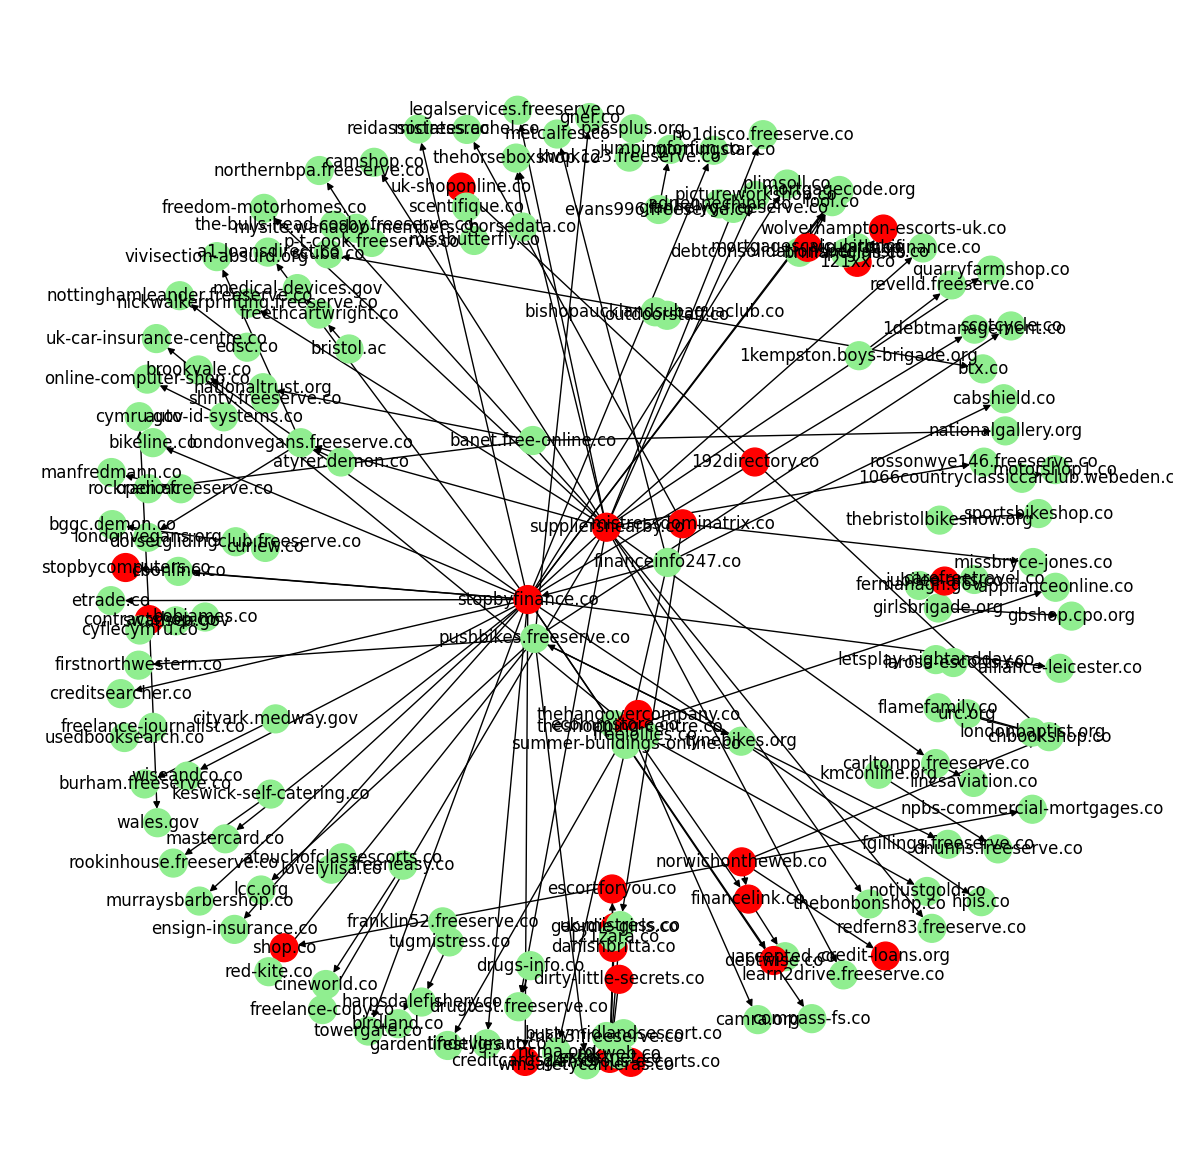

In [19]:
# Leave this code as-is, or modify slightly

colors = []
hostname_converted = {}

for hostname in g.nodes():
    # Assign colors to nodes according to spam/nonspam labels
    if hosts[name2id[hostname]]['label'] == 'spam':
        colors.append('red')
    elif hosts[name2id[hostname]]['label'] == 'nonspam':
        colors.append('lightgreen')
    else:
        colors.append('white')

    # Shorten the hostnames to generate labels
    label = hostname.replace("www.", "").replace(".uk", "")
    hostname_converted[hostname] = label

# Notice that if you re-run this cell the layout will be different every time
plt.figure(figsize=(15, 15))
plt.axis('off')
pos = nx.spring_layout(g)
nx.draw_networkx(g, pos, with_labels=True, node_size=400, node_color=colors, labels=hostname_converted)

El gráfico muestra una red de conexiones entre distintos dominios web. Los nodos rojos representan sitios clasificados como spam y los verdes como no spam. Se observa que varios nodos rojos están en el centro conectando con muchos verdes mayoritariamente en los bordes, lo que indica posibles intentos de los sitios spam por vincularse con dominios legítimos para difundir contenido spam.

In [48]:
total_edges = 0
spam_source_edges = 0
spam_to_nonspam_edges = 0
spam_source_total = 0

with gzip.open(INPUT_EDGES_FILENAME, "rt", encoding="utf-8") as input_file:
    reader = csv.DictReader(input_file, delimiter=',', quotechar='"')
    for record in reader:
        source_id = int(record["source"])
        dest_id = int(record["destination"])
        
        if source_id in hosts and dest_id in hosts:
            total_edges += 1
            source_label = hosts[source_id]['label']
            dest_label = hosts[dest_id]['label']
            
            # Contar edges donde source es spam
            if source_label == 'spam':
                spam_source_edges += 1
                
                # Contar edges spam->nonspam
                if dest_label == 'nonspam':
                    spam_to_nonspam_edges += 1
            
            # Contar total de edges desde nodos spam (para probabilidad condicional)
            if source_label == 'spam':
                spam_source_total += 1

prob_spam_source = spam_source_edges / total_edges if total_edges > 0 else 0
prob_joint_spam_nonspam = spam_to_nonspam_edges / total_edges if total_edges > 0 else 0
prob_conditional_spam_nonspam = spam_to_nonspam_edges / spam_source_total if spam_source_total > 0 else 0

print(f"Total de edges: {total_edges:,}")
print(f"Edges desde nodos spam: {spam_source_edges:,}")
print(f"Edges spam->nonspam: {spam_to_nonspam_edges:,}")
print()
print(f"P(edge desde spam) = {prob_spam_source:.4f} (Probabilidad marginal)")
print(f"P(spam->nonspam) = {prob_joint_spam_nonspam:.4f} (Probabilidad conjunta)")
print(f"P(nonspam | spam) = {prob_conditional_spam_nonspam:.4f} (Probabilidad condicional)")

Total de edges: 1,836,441
Edges desde nodos spam: 20,616
Edges spam->nonspam: 1,020

P(edge desde spam) = 0.0112 (Probabilidad marginal)
P(spam->nonspam) = 0.0006 (Probabilidad conjunta)
P(nonspam | spam) = 0.0495 (Probabilidad condicional)


P(edge desde spam) = 0.0112: Solo el 1.12% de todos los enlaces provienen de hosts spam. Esto es consistente con que los hosts spam son una minoría en la web, pero aún así tienen presencia significativa.

P(spam->nonspam) = 0.0006: La probabilidad conjunta es muy baja (0.06%), lo que indica que los enlaces directos de spam a nonspam son relativamente raros en el contexto de toda la red.

P(nonspam | spam) = 0.0495: Cuando un host spam crea un enlace, hay aproximadamente un 5% de probabilidad de que apunte a un sitio legítimo (nonspam). Esto muestra una estrategia clara de los spammers, usan principalmente redes propias (95% de sus enlaces), pero reservan un 5% para enlazar sitios legítimos y camuflarse.

# 2. Compute the degree of each node

In [20]:
# Leave this code as-is

# Initialize id2degree dict
id2degree = {}
N = len(hosts)
for nodeid in range(N):
    id2degree[nodeid] = 0

In [ ]:
id2degree = {}
with gzip.open(INPUT_EDGES_FILENAME, "rt", encoding="utf-8") as input_file:
    reader = csv.DictReader(input_file, delimiter=',', quotechar='"')
    for record in reader:
        source_id = int(record["source"])
        dest_id = int(record["destination"])
        
        if source_id in hosts:
            if source_id not in id2degree:
                id2degree[source_id] = 1
            else:
                id2degree[source_id] += 1

In [26]:
# Leave this cell as-is

for nodeid in [61914, 479, 62730]:
    print(f"{hosts[nodeid]['name']}: degree {id2degree[nodeid]}")

www.instrumentfinance.co.uk: degree 262
amazon.co.uk: degree 6
www.iso9000uk.co.uk: degree 38


# 3. Compute PageRank

In [27]:
# Leave this cell as-is

ITERATIONS = 25
ALPHA = 0.91

pagerank = [1.0/N] * N
pagerank_aux = [0.0] * N

In [33]:
pagerank_prev = [0.0] * N

for iteration in range(ITERATIONS):
    print(f"Iteration {iteration+1} of {ITERATIONS}")
    
    with gzip.open(INPUT_EDGES_FILENAME, "rt", encoding="utf-8") as input_file:
        reader = csv.DictReader(input_file, delimiter=',', quotechar='"')
        for record in reader:
            source_id = int(record["source"])
            dest_id = int(record["destination"])
            if source_id in hosts and dest_id in hosts:
                if id2degree[source_id] > 0:
                    pagerank_aux[dest_id] += (pagerank[source_id] / id2degree[source_id])
    
    for i in range(N):
        pagerank_prev[i] = pagerank[i]
    
    for i in range(N):
        pagerank[i] = ALPHA * pagerank_aux[i] + (1.0 - ALPHA) * (1.0 / N)
    
    total = sum(pagerank)
    for i in range(N):
        pagerank[i] /= total
    
    delta = 0.0
    for i in range(N):
        delta += abs(pagerank[i] - pagerank_prev[i])
    
    print(f"Delta: {delta:.4f}")
    
    for i in range(N):
        pagerank_aux[i] = 0.0

Iteration 1 of 25
Delta: 0.6643
Iteration 2 of 25
Delta: 0.1409
Iteration 3 of 25
Delta: 0.0718
Iteration 4 of 25
Delta: 0.0469
Iteration 5 of 25
Delta: 0.0357
Iteration 6 of 25
Delta: 0.0294
Iteration 7 of 25
Delta: 0.0257
Iteration 8 of 25
Delta: 0.0236
Iteration 9 of 25
Delta: 0.0228
Iteration 10 of 25
Delta: 0.0228
Iteration 11 of 25
Delta: 0.0230
Iteration 12 of 25
Delta: 0.0233
Iteration 13 of 25
Delta: 0.0236
Iteration 14 of 25
Delta: 0.0240
Iteration 15 of 25
Delta: 0.0243
Iteration 16 of 25
Delta: 0.0247
Iteration 17 of 25
Delta: 0.0251
Iteration 18 of 25
Delta: 0.0255
Iteration 19 of 25
Delta: 0.0259
Iteration 20 of 25
Delta: 0.0263
Iteration 21 of 25
Delta: 0.0267
Iteration 22 of 25
Delta: 0.0271
Iteration 23 of 25
Delta: 0.0275
Iteration 24 of 25
Delta: 0.0279
Iteration 25 of 25
Delta: 0.0283


# 4. Nodes with largest values of PageRank

In [37]:
def print_top_pagerank(pagerank, hosts, total_list=20):
    hosts_by_pagerank = sorted(enumerate(pagerank), key=lambda x: x[1], reverse=True)
    
    print(f"Top {total_list} hosts by PageRank:")
    print("-" * 80)
    print(f"{'Rank':<4} {'Host ID':<8} {'PageRank':<12} {'Label':<10} {'Host Name'}")
    print("-" * 80)
    
    for rank, (host_id, score) in enumerate(hosts_by_pagerank[:total_list], 1):
        host_info = hosts[host_id]
        print(f"{rank:<4} {host_id:<8} {score:.6f}   {host_info['label']:<10} {host_info['name']}")

print_top_pagerank(pagerank, hosts, total_list=20)

Top 20 hosts by PageRank:
--------------------------------------------------------------------------------
Rank Host ID  PageRank     Label      Host Name
--------------------------------------------------------------------------------
1    81634    0.006051   unlabeled  www.opsi.gov.uk
2    9215     0.005060   unlabeled  www.aa-roundabout.org.uk
3    12326    0.005044   unlabeled  www.alcoholics-anonymous.org.uk
4    65466    0.004847   unlabeled  www.kelkoo.co.uk
5    6475     0.004199   unlabeled  shopping.kelkoo.co.uk
6    60715    0.003637   unlabeled  www.ico.gov.uk
7    10990    0.003195   unlabeled  www.adobe.co.uk
8    42757    0.002914   unlabeled  www.dti.gov.uk
9    39774    0.002811   unlabeled  www.defra.gov.uk
10   37012    0.002691   unlabeled  www.croner.co.uk
11   40999    0.002431   unlabeled  www.direct.gov.uk
12   29600    0.002430   unlabeled  www.cch.co.uk
13   34406    0.002422   unlabeled  www.communities.gov.uk
14   40559    0.002313   unlabeled  www.dfes.gov.

Sitios gubernamentales (opsi.gov.uk, ico.gov.uk, dti.gov.uk, etc.): Alta autoridad natural, muchos enlaces entrantes de instituciones

Kelkoo.co.uk: Comparador de precios muy popular en UK, recibe muchos enlaces de comercios

Sitios de servicios públicos (alcoholics-anonymous.org.uk): Alta relevancia social

Adobe.co.uk: Software, muchos enlaces desde documentación técnica

Distribución por categoría en el Top 20:

Gobierno: 9 sitios (45%) - dominan el ranking

Comercial: 6 sitios (30%) - comparadores y servicios

Educativo: 0 sitios

Servicios públicos/otros: 5 sitios (25%)

# 5. Run non-spam PageRank

In [39]:
id2nsdegree = {}

with gzip.open(INPUT_EDGES_FILENAME, "rt", encoding="utf-8") as input_file:
    reader = csv.DictReader(input_file, delimiter=',', quotechar='"')
    for record in reader:
        source_id = int(record["source"])
        dest_id = int(record["destination"])
        
        # Solo contar enlaces donde source y destination NO son spam
        if (source_id in hosts and dest_id in hosts and 
            hosts[source_id]['label'] != "spam" and 
            hosts[dest_id]['label'] != "spam"):
            
            # Contar out-degree del source (solo enlaces no-spam)
            if source_id not in id2nsdegree:
                id2nsdegree[source_id] = 1
            else:
                id2nsdegree[source_id] += 1



In [41]:
# Leave this cell as-is

for nodeid in [61914, 479, 62730]:
    print(f"{hosts[nodeid]['name']}: normal degree {id2degree[nodeid]} nospam degree {id2nsdegree[nodeid]}")

www.instrumentfinance.co.uk: normal degree 262 nospam degree 258
amazon.co.uk: normal degree 6 nospam degree 6
www.iso9000uk.co.uk: normal degree 38 nospam degree 37


In [43]:
# Inicializar PageRank sin spam
N_nospam = len([h for h in hosts.values() if h['label'] != "spam"])
nspagerank = [1.0 / N_nospam] * N
nspagerank_prev = [0.0] * N
nspagerank_aux = [0.0] * N

ITERATIONS = 25
ALPHA = 0.91

print("Calculando PageRank sin spam...")
for iteration in range(ITERATIONS):
    print(f"Iteration {iteration+1} of {ITERATIONS}")
    
    # Leer el grafo y acumular en nspagerank_aux (solo enlaces no-spam)
    with gzip.open(INPUT_EDGES_FILENAME, "rt", encoding="utf-8") as input_file:
        reader = csv.DictReader(input_file, delimiter=',', quotechar='"')
        for record in reader:
            source_id = int(record["source"])
            dest_id = int(record["destination"])
            
            # Solo procesar enlaces donde source y destination NO son spam
            if (source_id in hosts and dest_id in hosts and 
                hosts[source_id]['label'] != "spam" and 
                hosts[dest_id]['label'] != "spam" and
                source_id in id2nsdegree and id2nsdegree[source_id] > 0):
                
                nspagerank_aux[dest_id] += (nspagerank[source_id] / id2nsdegree[source_id])
    
    # Guardar valores actuales antes de actualizar
    for i in range(N):
        nspagerank_prev[i] = nspagerank[i]
    
    # Actualizar PageRank
    for i in range(N):
        nspagerank[i] = ALPHA * nspagerank_aux[i] + (1.0 - ALPHA) * (1.0 / N_nospam)
    
    # Normalizar (asegurar que suma = 1.0)
    total = sum(nspagerank)
    for i in range(N):
        nspagerank[i] /= total
    
    # Calcular delta
    delta = 0.0
    for i in range(N):
        delta += abs(nspagerank[i] - nspagerank_prev[i])
    
    print(f"Delta: {delta:.4f}")
    
    # Reiniciar nspagerank_aux para la siguiente iteración
    for i in range(N):
        nspagerank_aux[i] = 0.0

print("\nPageRank sin spam completado!")

Calculando PageRank sin spam...
Iteration 1 of 25
Delta: 1.1499
Iteration 2 of 25
Delta: 0.4814
Iteration 3 of 25
Delta: 0.2266
Iteration 4 of 25
Delta: 0.1259
Iteration 5 of 25
Delta: 0.0798
Iteration 6 of 25
Delta: 0.0547
Iteration 7 of 25
Delta: 0.0400
Iteration 8 of 25
Delta: 0.0302
Iteration 9 of 25
Delta: 0.0240
Iteration 10 of 25
Delta: 0.0197
Iteration 11 of 25
Delta: 0.0169
Iteration 12 of 25
Delta: 0.0153
Iteration 13 of 25
Delta: 0.0147
Iteration 14 of 25
Delta: 0.0146
Iteration 15 of 25
Delta: 0.0145
Iteration 16 of 25
Delta: 0.0146
Iteration 17 of 25
Delta: 0.0146
Iteration 18 of 25
Delta: 0.0148
Iteration 19 of 25
Delta: 0.0149
Iteration 20 of 25
Delta: 0.0150
Iteration 21 of 25
Delta: 0.0152
Iteration 22 of 25
Delta: 0.0154
Iteration 23 of 25
Delta: 0.0156
Iteration 24 of 25
Delta: 0.0158
Iteration 25 of 25
Delta: 0.0159

PageRank sin spam completado!


In [44]:
print_top_pagerank(nspagerank, hosts, total_list=20)

Top 20 hosts by PageRank:
--------------------------------------------------------------------------------
Rank Host ID  PageRank     Label      Host Name
--------------------------------------------------------------------------------
1    81634    0.006528   unlabeled  www.opsi.gov.uk
2    60715    0.003837   unlabeled  www.ico.gov.uk
3    10990    0.003398   unlabeled  www.adobe.co.uk
4    65466    0.003390   unlabeled  www.kelkoo.co.uk
5    42757    0.003129   unlabeled  www.dti.gov.uk
6    12326    0.003105   unlabeled  www.alcoholics-anonymous.org.uk
7    39774    0.003014   unlabeled  www.defra.gov.uk
8    6475     0.002891   unlabeled  shopping.kelkoo.co.uk
9    9215     0.002828   unlabeled  www.aa-roundabout.org.uk
10   40999    0.002610   unlabeled  www.direct.gov.uk
11   34406    0.002608   unlabeled  www.communities.gov.uk
12   40559    0.002489   unlabeled  www.dfes.gov.uk
13   40612    0.002125   unlabeled  www.dh.gov.uk
14   58631    0.001996   unlabeled  www.hmso.gov.u

**Resumen diferencias PageRank vs. No-Spam:**

- **Gobierno**: Se fortalece (más posiciones altas)
- **Kelkoo/comercios**: Pierden ranking  
- **Algunos unlabeled**: Caen drásticamente (posible spam)
- **Distribución**: Más equilibrada sin spam

**Conclusión**: El spam inflaba algunos sitios comerciales. Sin spam, domina la autoridad real (gobierno).

# 6. Compute spam gain

In [46]:
# Calcular la ganancia para cada host
gain = []
for i in range(N):
    if nspagerank[i] > 0:  # Evitar división por cero
        gain_value = pagerank[i] / nspagerank[i]
    else:
        gain_value = float('inf')  # Si no-spam PageRank es 0, ganancia infinita
    gain.append(gain_value)

hosts_with_gain = []
for i in range(N):
    host_info = hosts[i]
    hosts_with_gain.append({
        'host_id': i,
        'name': host_info['name'],
        'label': host_info['label'],
        'gain': gain[i],
        'pagerank': pagerank[i],
        'nspagerank': nspagerank[i]
    })

# Ordenar
hosts_by_gain = sorted(hosts_with_gain, key=lambda x: x['gain'], reverse=True)

# Mostrar top 50 hosts por ganancia
print("Top 50 hosts por ganancia (PageRank Normal / PageRank Sin Spam)")
print("=" * 100)
print(f"{'Rank':<4} {'Host ID':<8} {'Gain':<8} {'Label':<10} {'PageRank':<12} {'No-Spam PR':<12} {'Host Name'}")
print("=" * 100)

for rank, host_data in enumerate(hosts_by_gain[:50], 1):
    pr_sci = f"{host_data['pagerank']:.2e}"
    nspr_sci = f"{host_data['nspagerank']:.2e}"
    
    print(f"{rank:<4} {host_data['host_id']:<8} {host_data['gain']:<8.2f} {host_data['label']:<10} "
          f"{pr_sci:<12} {nspr_sci:<12} {host_data['name']}")

Top 50 hosts por ganancia (PageRank Normal / PageRank Sin Spam)
Rank Host ID  Gain     Label      PageRank     No-Spam PR   Host Name
1    62200    239.73   spam       2.13e-04     8.88e-07     www.into.demon.co.uk
2    11757    148.35   unlabeled  1.58e-04     1.07e-06     www.aili.co.uk
3    75287    136.72   spam       1.21e-04     8.88e-07     www.missionfish.org.uk
4    98924    129.75   spam       1.15e-04     8.88e-07     www.statistics.006.free-counter.co.uk
5    46303    115.93   spam       1.03e-04     8.88e-07     www.escortnet.co.uk
6    57785    113.23   spam       1.01e-04     8.88e-07     www.hertfordshiremobilediscos.co.uk
7    64095    91.72    spam       8.14e-05     8.88e-07     www.jlc.me.uk
8    52597    43.57    spam       3.87e-05     8.88e-07     www.geordie-girls.co.uk
9    107646   33.30    spam       2.96e-05     8.88e-07     www.uk-shoponline.co.uk
10   66838    33.15    spam       2.94e-05     8.88e-07     www.kompass.co.uk
11   60824    25.84    spam      

Spam gain: Es un número que te dice cuánto se beneficia una página del spam. Si el gain es 100, significa que con spam tiene 100 veces mejor ranking que sin spam.

**Sitios con mayor ganancia:**
- **Spam confirmado**: Escorts, tiendas online, contadores gratuitos
- **Algunos unlabeled**: Posiblemente spam no detectado

**Efectos del PageRank sin spam:**
- **Penaliza sitios spam**: Su ranking cae drásticamente
- **Beneficia sitios legítimos**: Gobierno, educación, servicios reales


<font size="+2" color="#003300">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>